# Argo Reveals the Scales and Provenance of Equatorial Island Upwelling Systems
**Karnauskas & Giglio, 2022** | Reproduction of Figures 1–4 using Argovis API

Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

This notebook reproduces key figures from Karnauskas & Giglio (2022), demonstrating how to query Argo profiles and gridded products (NOAA SST, RG09 temperature) through Argovis to investigate equatorial island upwelling systems near the Galápagos and Gilbert Islands.


## Learning Goals

By the end of this activity, you will be able to:

1. **Identify upwelling signatures** in the sea surface temperature (SST) field — locate where SST is anomalously cold and explain why.
2. **Describe the vertical temperature structure** associated with upwelling — how the subsurface temperature profile changes inside versus outside an upwelling zone.
3. **Hypothesize mechanisms** that drive upwelling near equatorial islands, including wind-driven divergence, topographic steering, and equatorial dynamics.
4. **Evaluate observational data** — consider how spatial and temporal sampling biases might affect time-mean results and seasonal interpretation.
5. **Compare two upwelling systems** (Galápagos and Gilbert Islands) and explain similarities and differences in their subsurface thermal signatures.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Register and copy the key provided.
3. Paste it below, replacing `'guest'`.

## Setup: import libraries and functions

In [1]:
# ── Imports — run this cell first, do not modify ───────────────────────────
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import matplotlib.dates as mdates
from scipy.stats import sem
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

APIKEY  = 'guest'  # ← paste your key here
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `traverse_query` — loop over all region × time × dataset combinations and call the Argovis API
- `plot_maps` — scatter profile locations on a map
- `_arr` — safely convert Profile.getvar() output to a plain float ndarray
- `_safe_interp` — interpolate profiles onto standard levels, skipping profiles with fewer than 2 valid levels
- `parse_profiles` — parse raw Argovis metadata into a DataFrame with lon, lat, time, year, month
- `build_grid` — bin profiles by longitude (and optionally latitude), returning an xarray Dataset of mean temperature
- `plot_section` — plot a mean temperature cross-section panel
- `plot_anomaly_zoom` — plot a zonal anomaly panel, zoomed on a specified inset region
- `plot_profiles_comparison` — plot mean profiles with 95% CI for west-of-upwelling vs within-upwelling zones

In [2]:
# ── Helper functions — run, do not modify ──────────────────────────────────
from notebook_helpers.functions import traverse_query, plot_maps
from notebook_helpers.functions_UPWELLING import plot_section, plot_anomaly_zoom, plot_profiles_comparison
from notebook_helpers.functions_candidates_for_functions import compute_n2_profile, build_grid, _arr, _safe_interp, parse_profiles

## Setup: configuration

**⚠️ First run: do not modify anything in this cell.** Run it as-is to reproduce the full 2000–2021 record used in the paper. Querying all regions and datasets takes **approximately 10–15 minutes** — this is normal for a 20-year global record spanning two ocean basins.

All downstream cells read from the variables defined here. Longitudes follow Argovis convention (negative °W); converted to °E with `% 360` where needed.

> **Heads-up — Question 4 (end of notebook):** Once you have worked through the notebook, you will be asked to come back here, shorten the time period, and re-run all cells to explore how the results change. **Do not do that now** — complete the notebook in order first.

In [3]:
# ── Regions — DO NOT MODIFY ────────────────────────────────────────────────
# For grid queries (RG09, SST) — wider boxes
regions_hist = [
    {'box': [[-100, -5], [-85, 5]]},   # Galápagos — data from 260°E to 275°E
    {'box': [[-195, -5], [-180, 5]]},  # Gilberts — data from 165°E to 180°E
]

region_names = ["Galápagos", "Gilberts"]

# For Galápagos Argo section (Figure 3) — negative longitudes
regions_section_gal = [{'box': [[-95, -1], [-90, 0]]}]

# For Gilberts Argo sections (Figure 4) — stored as negative but plotted as positive °E
regions_gil_north = [{'box': [[-193, 0], [-183, 2]]}]   # 167°E–177°E, 0°N–2°N
regions_gil_south = [{'box': [[-193, -2], [-183, 0]]}]  # 167°E–177°E, 2°S–0°

# ── Time period ✏️ — MODIFY ONLY WHEN INSTRUCTED (see Question 4) ──────────
# Full record — replicates the paper's figures; run this on your first pass
time_periods = [{'startDate': '2000-01-01T00:00:00Z', 'endDate': '2021-12-31T00:00:00Z'}]
# Try shorter windows to explore how results change (uncomment one at a time when instructed):
# time_periods = [{'startDate': '2015-01-01T00:00:00Z', 'endDate': '2021-12-31T00:00:00Z'}]  # ~7 yr
# time_periods = [{'startDate': '2010-01-01T00:00:00Z', 'endDate': '2021-12-31T00:00:00Z'}]  # ~12 yr
# time_periods = [{'startDate': '2005-01-01T00:00:00Z', 'endDate': '2021-12-31T00:00:00Z'}]  # ~17 yr

# ── Data collections — DO NOT MODIFY ───────────────────────────────────────
grids = {
    'timeseries/noaasst': 'sst',
    'grids/rg09':         'rg09_temperature',
}
insitu = {'argo': 'temperature,1'}

INTERPOLATION_LEVELS = avh.rg_levels()

# ── Plotting conventions — DO NOT MODIFY ───────────────────────────────────
REGION_COLORS = ['darkblue', 'darkorange']
DEPTH_YLIM = None

# ── 1 m vertical grid (paper: 5–300 m at 1 m resolution) ──────────────────
fine_depths = np.arange(5, 301, 1.0)   # 296 levels

## Step 1 — Query gridded products (SST, RG09)

In [4]:
# ── Step 1: Query gridded products — run, do not modify ────────────────────
grid_results = traverse_query(regions_hist, time_periods, grids, avh.queryGrid, APIKEY, APIROOT)


## Step 2 — Query Argo metadata (for sampling statistics)

In [5]:
# ── Step 2: Query Argo metadata — run, do not modify ───────────────────────
insitu_metadata = traverse_query(
    regions_hist, time_periods, insitu, avh.query,
    APIKEY, APIROOT,
    qsp_base={'compression': 'minimal'}
)

## Step 3 — Query and interpolate Argo section profiles

In [6]:
# ── Step 3: Query Argo profiles — run, do not modify ───────────────────────
# Galápagos section profiles
insitu_raw_gal = traverse_query(regions_section_gal, time_periods, insitu, avh.queryProfile, APIKEY, APIROOT)
profiles_gal   = _safe_interp(insitu_raw_gal['argo'][0][0], list(fine_depths))
print(f"Galápagos profiles: {len(profiles_gal)}")

# Gilberts section profiles — North
insitu_raw_north   = traverse_query(regions_gil_north, time_periods, insitu, avh.queryProfile, APIKEY, APIROOT)
profiles_gil_north = _safe_interp(insitu_raw_north['argo'][0][0], INTERPOLATION_LEVELS)

# Gilberts section profiles — South
insitu_raw_south   = traverse_query(regions_gil_south, time_periods, insitu, avh.queryProfile, APIKEY, APIROOT)
profiles_gil_south = _safe_interp(insitu_raw_south['argo'][0][0], INTERPOLATION_LEVELS)

print(f"Gilberts north profiles: {len(profiles_gil_north)}")
print(f"Gilberts south profiles: {len(profiles_gil_south)}")

Galápagos profiles: 461
Gilberts north profiles: 1854
Gilberts south profiles: 1751


## Visualization — Figure 1: Mean SST

The two maps below show the **time-mean sea surface temperature** from NOAA OISST around the Gilbert Islands (left) and Galápagos Islands (right). Warmer colors indicate higher SST; cooler colors indicate lower SST. Look for cold anomalies near the islands — these are the surface signature of upwelling.

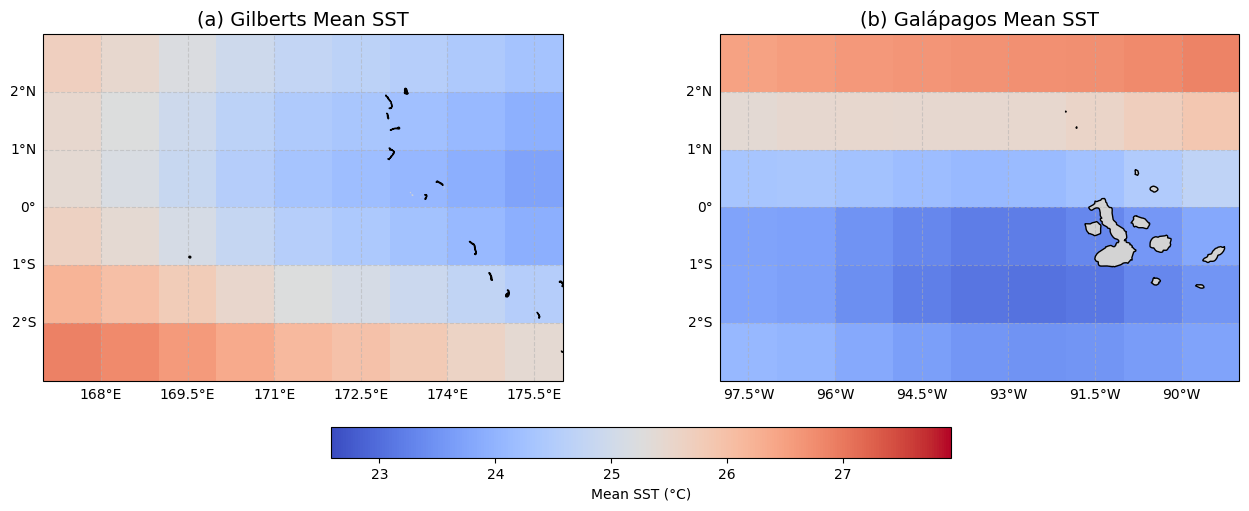

In [7]:
# ── Figure 1: SST — run, do not modify ─────────────────────────────────────
sst_gil = grid_results['timeseries/noaasst'][1][0].sst.mean(dim='timestamp').squeeze()
sst_gal = grid_results['timeseries/noaasst'][0][0].sst.mean(dim='timestamp').squeeze()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})

extents = [
    [167, 176, -3, 3],   # Gilberts
    [262, 271, -3, 3],   # Galápagos
]

for ax, data, title, extent in zip(axes,
                                    [sst_gil, sst_gal],
                                    ['(a) Gilberts Mean SST', '(b) Galápagos Mean SST'],
                                    extents):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)
    p = data.plot(ax=ax, x='longitude', y='latitude', transform=ccrs.PlateCarree(),
                  cmap='coolwarm', zorder=1, add_colorbar=False)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = gl.right_labels = False
    ax.set_title(title, fontsize=14)

fig.colorbar(p, ax=axes, orientation='horizontal', shrink=0.5, pad=0.1, label='Mean SST (°C)')
plt.show()


## ✏️ Student Work — Question 1: SST and the Upwelling Signature

Look at the mean SST maps above.

**Part A — Galápagos**

1. Where is SST coldest relative to the surrounding open ocean near the Galápagos? Describe the spatial pattern — is the cold signal on the eastern or western side of the islands, and how far does it extend?
2. What does the anomalously cold SST tell you about where upwelling is most active?
3. What physical mechanism(s) could explain why SST is lower in this location? Think about wind patterns, the Coriolis effect, and the role of the islands themselves.

**Part B — Comparison with the Gilbert Islands**

Now compare the Galápagos SST map with the Gilbert Islands map generated above, and with **Figure 1 of Karnauskas & Giglio (2022)**.

4. In the paper's Figure 1, a distinct cold SST anomaly is visible **west of** the Gilbert Islands. Do you see the same cold region in the notebook plot? Why or why not?

   > 💡 *Hint: The SST product available through Argovis (NOAA OISST) has a native spatial resolution of **0.25°** (28 km at the equator). The SST product used to produce the paper's Figure 1 has a resolution of **0.1°** (11 km). How does the size of the cold anomaly west of the Gilberts compare to these two grid spacings? What does that tell you about the importance of dataset resolution for resolving small-scale upwelling signals?*

5. Based on your answers above, what differences and similarities do you see between the Galápagos and Gilbert Islands upwelling systems as revealed by SST alone?


*Double-click to edit this cell and write your answer.*

## Visualization — Figure 2: Argo Sampling

These panels show the **spatial and temporal distribution** of Argo profiles used in this study (2000–2021) for each region. The top row shows profile locations binned on a **0.5° longitude × 1° latitude** grid; the middle row shows the number of profiles per year; the bottom row shows the number of profiles per month across all years. Use this figure to assess whether the sampling is uniform enough to support a reliable time mean.

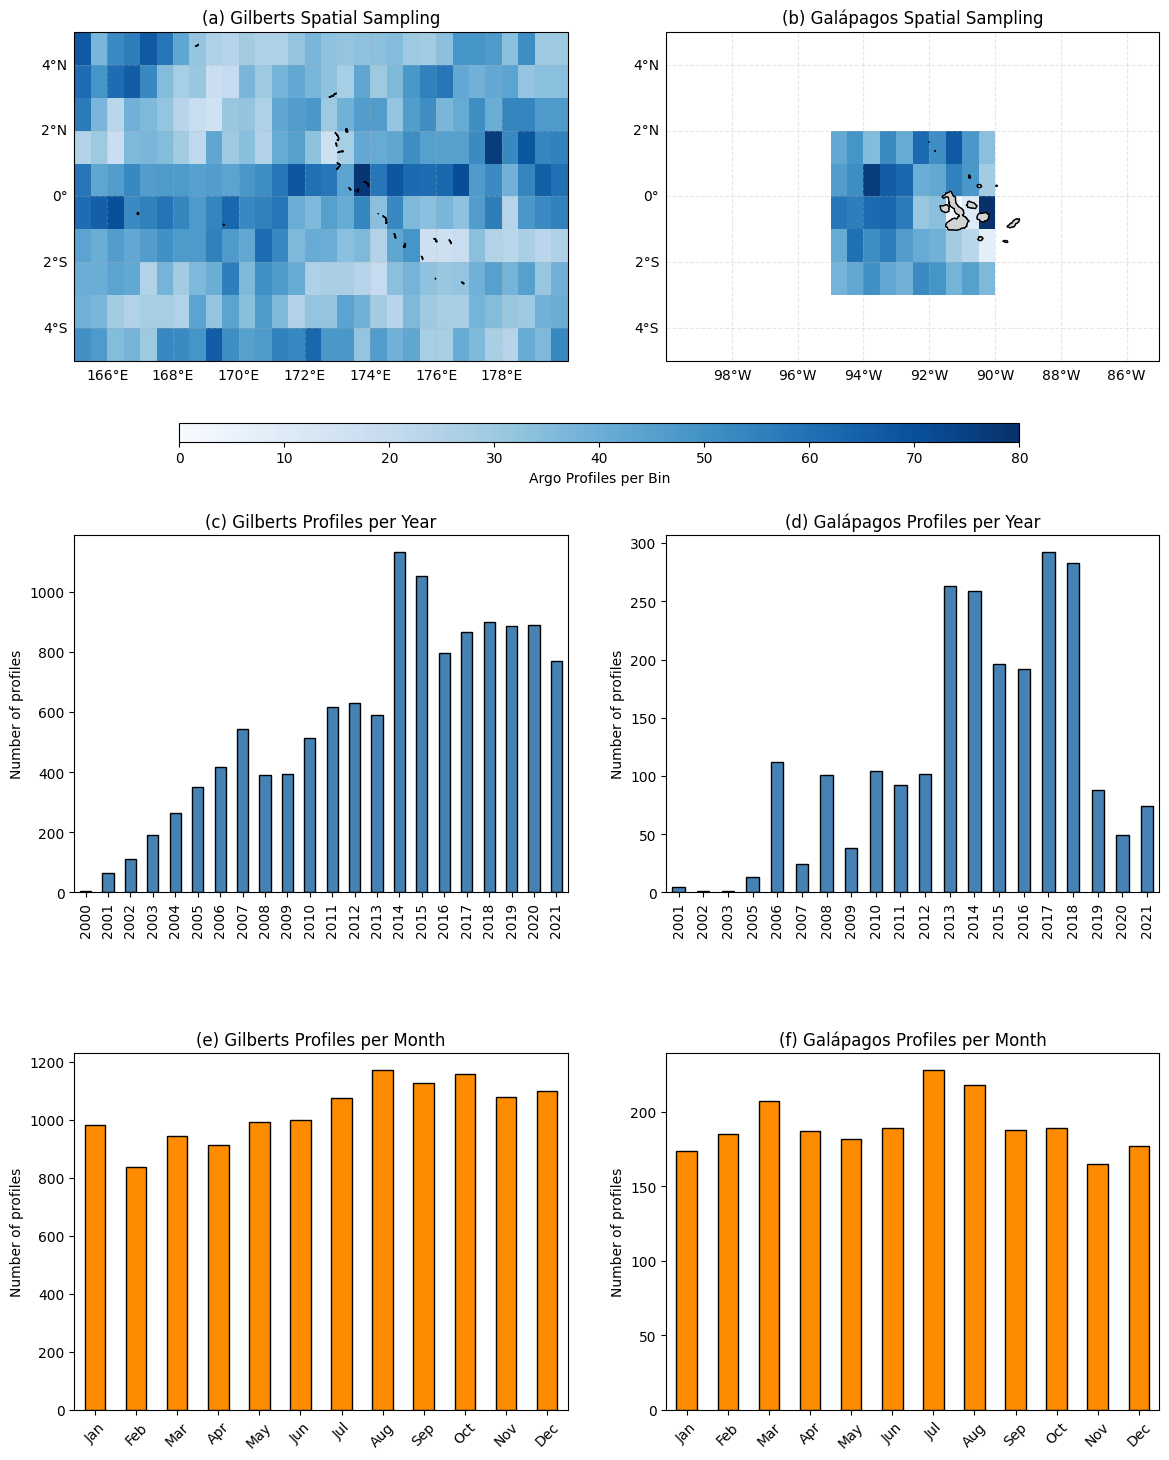

In [8]:
# ── Figure 2: Argo sampling — run, do not modify ────────────────────────────────
# Parse and spatially clip Galápagos to its deployment region
df_gil = parse_profiles(insitu_metadata['argo'][1])
df_gal = parse_profiles(insitu_metadata['argo'][0])
df_gal = df_gal[
    (df_gal['lon'] >= 265) & (df_gal['lon'] <= 270) &
    (df_gal['lat'] >= -3)  & (df_gal['lat'] <= 2)
].copy()

# Per-region config: map display extent, lon bin bounds, lat bin bounds
region_cfg = {
    'Gilberts': dict(
        map_ext   = [165, 180, -5,  5],
        lon_bounds= (165, 180),
        lat_bounds= ( -5,  5),
    ),
    'Galápagos': dict(
        map_ext   = [260, 275, -5,  5],
        lon_bounds= (265, 270),
        lat_bounds= ( -3,  2),
    ),
}

fig    = plt.figure(figsize=(14, 16))
proj   = ccrs.PlateCarree()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
labels = 'abcdef'

for col, (df, name) in enumerate([(df_gil, 'Gilberts'), (df_gal, 'Galápagos')]):
    cfg = region_cfg[name]
    ext = cfg['map_ext']
    dlon_min, dlon_max = cfg['lon_bounds']
    dlat_min, dlat_max = cfg['lat_bounds']

    # Spatial binning
    df_bin   = df[(df['lon'] >= dlon_min) & (df['lon'] <= dlon_max)]
    lon_bins = np.arange(dlon_min, dlon_max + 0.5, 0.5)
    lat_bins = np.arange(dlat_min, dlat_max + 1,   1.0)
    H, xe, ye = np.histogram2d(df_bin['lon'], df_bin['lat'], bins=[lon_bins, lat_bins])

    # (a/b) Spatial map
    ax   = fig.add_subplot(3, 2, col + 1, projection=proj)
    mesh = ax.pcolormesh(xe, ye, np.ma.masked_where(H == 0, H).T,
                         cmap='Blues', transform=proj, vmin=0, vmax=80, zorder=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_extent(ext, crs=proj)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
    gl.ylocator = mticker.MultipleLocator(2)
    gl.top_labels = gl.right_labels = False
    ax.set_title(f'({labels[col]}) {name} Spatial Sampling')

    # (c/d) Profiles per year
    ax = fig.add_subplot(3, 2, col + 3)
    df.groupby('year').size().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set(title=f'({labels[col+2]}) {name} Profiles per Year',
           ylabel='Number of profiles', xlabel='')

    # (e/f) Profiles per month
    ax = fig.add_subplot(3, 2, col + 5)
    df.groupby('month').size().reindex(range(1, 13), fill_value=0).plot(
        kind='bar', ax=ax, color='darkorange', edgecolor='black')
    ax.set_xticklabels(months, rotation=45)
    ax.set(title=f'({labels[col+4]}) {name} Profiles per Month',
           ylabel='Number of profiles', xlabel='')

plt.subplots_adjust(hspace=0.45, top=0.95, bottom=0.08)
cbar_ax = fig.add_axes([0.2, 0.685, 0.6, 0.012]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal', label='Argo Profiles per Bin')
plt.show()

## ✏️ Student Work — Question 2: Data Distribution and Sampling Bias

Look at the spatial and temporal distribution of Argo profiles shown in Figure 2.

1. Are profiles distributed evenly in space across each region? Are there gaps near the islands, along the equator, or at the edges of the domain?
2. Looking at the time panels, are profiles spread evenly across all months and years, or do you notice seasonal or interannual clustering?
3. If sampling is uneven in time, how might this affect the **time-mean temperature section** computed in Figures 3 and 4? Could the mean be biased toward a particular season? Would you expect that bias to make upwelling appear stronger or weaker than it truly is?

*Double-click to edit this cell and write your answer.*

## Visualization — Figure 3: Galápagos subsurface thermal signal

The three panels below show the subsurface temperature structure near the Galápagos Islands:

- **(a) Mean temperature cross-section** — temperature (°C) as a function of depth and longitude; cold water shoaling toward the island indicates upwelling
- **(b) Zonal anomaly** — temperature minus the zonal mean, highlighting the cold anomaly immediately west of and at the island
- **(c) Mean profiles** — vertical temperature profiles west of vs. within the upwelling zone, with 95% confidence intervals; use these for Question 3

### Binning — Galápagos
0.5°-wide bins every 0.25° longitude, averaged 1°S–0°S.
Fetch region extended to 90°W to capture profiles near the island boundary.
Domain capped at 268.25°E for analysis; easternmost bin (268.25°E) = "within upwelling".

In [9]:
# ── Galápagos binning — run, do not modify ─────────────────────────────────
x_centers_gal = np.arange(265.25, 269.76, 0.25)
grid_gal, combined_gal = build_grid(profiles_gal, x_centers_gal, 0.25,
                                     lat_min=-1.0, lat_max=0.0,
                                     use_rawdata=True, profile_levels=list(fine_depths))
print("Gal:      ", combined_gal.temperature.shape)


Gal:       (19, 296)


### Plot
Panels: (a) mean temperature cross-section, (b) zonal anomaly zoomed to inset, (c) mean profiles west of and within the upwelling zone with 95% CI.

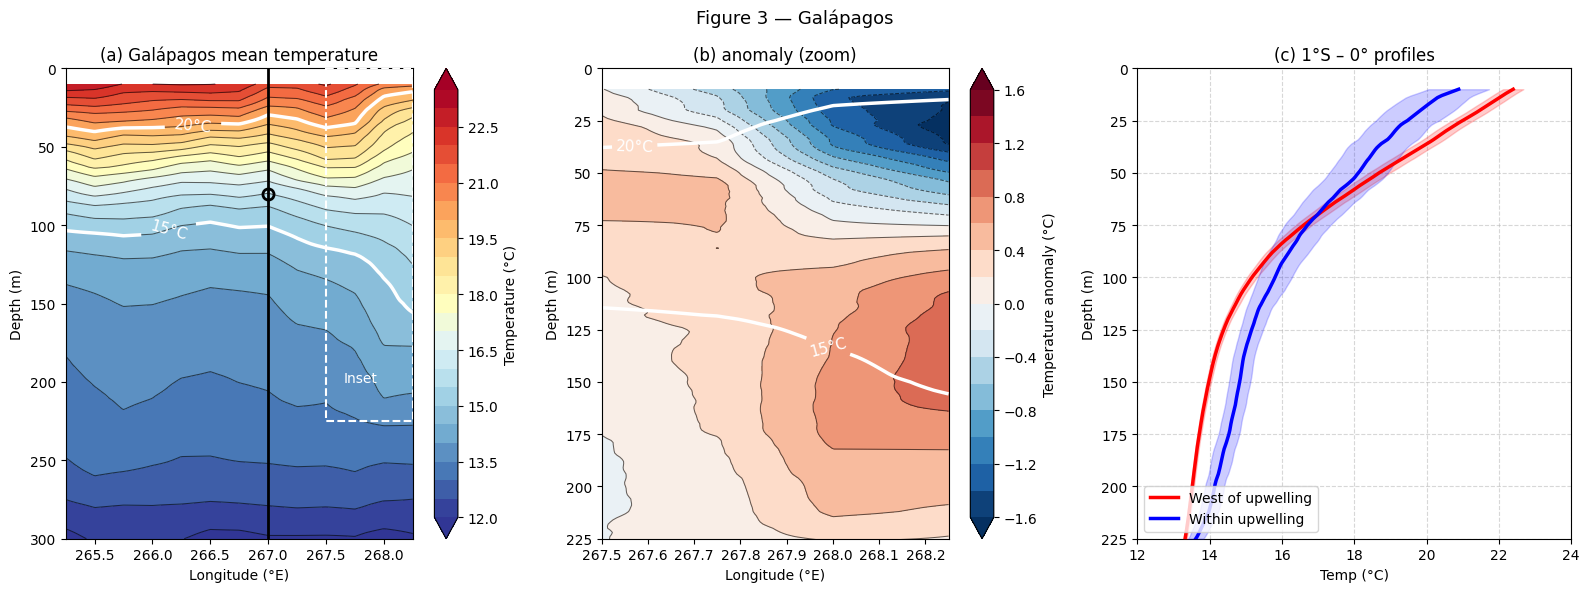

In [10]:
# ── Figure 3: Galápagos — run, do not modify ────────────────────────────────────
depth_mask_gal = (fine_depths >= 10) & (fine_depths <= 300)
depth_mask_225 = (fine_depths >= 10) & (fine_depths <= 225)
depth_arr_225  = fine_depths[depth_mask_225]

inset_lon_min, inset_lon_max = 267.5, 268.25

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

plot_section(axes[0], combined_gal, depth_mask_gal, 267.0,
             inset_lon_min, inset_lon_max, 0, 225,
             label='(a) Galápagos',
             levels=np.arange(12, 24, 0.5), iso_levels=[15, 20],
             ylim=(300, 0),
             domain_cap=268.25, smooth=True)

axes[0].plot(267.0, 80, 'o', color='black', markersize=8,
             markerfacecolor='none', markeredgewidth=2, zorder=5)

plot_anomaly_zoom(axes[1], combined_gal, depth_mask_gal,
                  inset_lon_min, inset_lon_max, 0, 225,
                  label='(b)',
                  anom_levels=np.arange(-1.6, 1.7, 0.2), iso_levels=[15, 20],
                  domain_cap=268.25, smooth=True)

plot_profiles_comparison(axes[2], profiles_gal, depth_mask_225, depth_arr_225,
                         upwelling_lon=(267.75, 268.25), west_of=267.75,
                         label='(c) 1°S – 0°',
                         xlim=(12, 24), ylim=(225, 0))

plt.suptitle('Figure 3 — Galápagos', fontsize=13)
plt.tight_layout()
plt.show()


## Visualization — Figure 4: Gilbert Islands subsurface thermal signal

Same three-panel layout as Figure 3, shown separately for the **northern** (0°–2°N) and **southern** (1.5°S–0°) flanks of the Gilbert Islands. Compare the depth and magnitude of the cold anomaly between the two flanks, and against the Galápagos signal in Figure 3.

### Binning — Gilberts
1°-wide bins every 0.25° longitude. North: 0°–2°N. South: 1.5°S–0°.

In [11]:
# ── Gilbert Islands binning — run, do not modify ───────────────────────────
x_centers_gil              = np.arange(166.5, 180.0, 0.25)
grid_north, combined_north = build_grid(profiles_gil_north, x_centers_gil, 0.5,
                                        use_rawdata=True,
                                        profile_levels=INTERPOLATION_LEVELS)  
grid_south, combined_south = build_grid(profiles_gil_south, x_centers_gil, 0.5,
                                        use_rawdata=True,
                                        profile_levels=INTERPOLATION_LEVELS)

### Plot
Each figure row consists of three panels produced by separate functions:
- `plot_section` — mean temperature cross-section
- `plot_anomaly_zoom` — zonal anomaly, zoomed on the inset region
- `plot_profiles_comparison` — mean profiles west of vs within the upwelling zone, with 95% CI

For Figure 4, the row is called separately for the northern and southern Gilbert Islands.

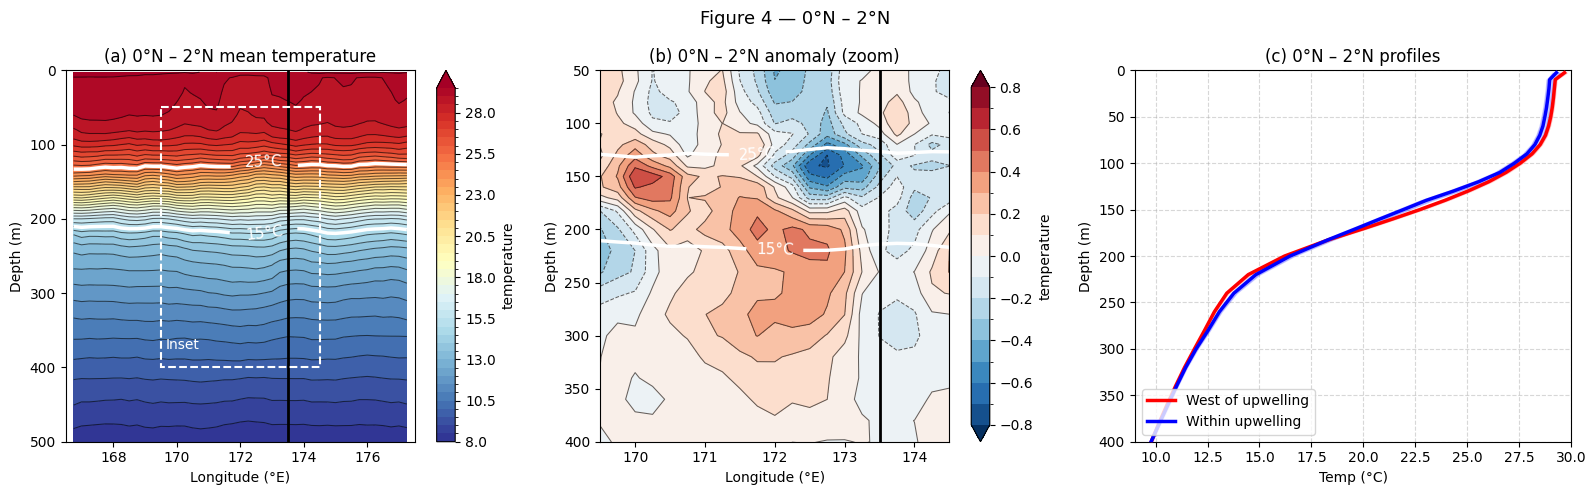

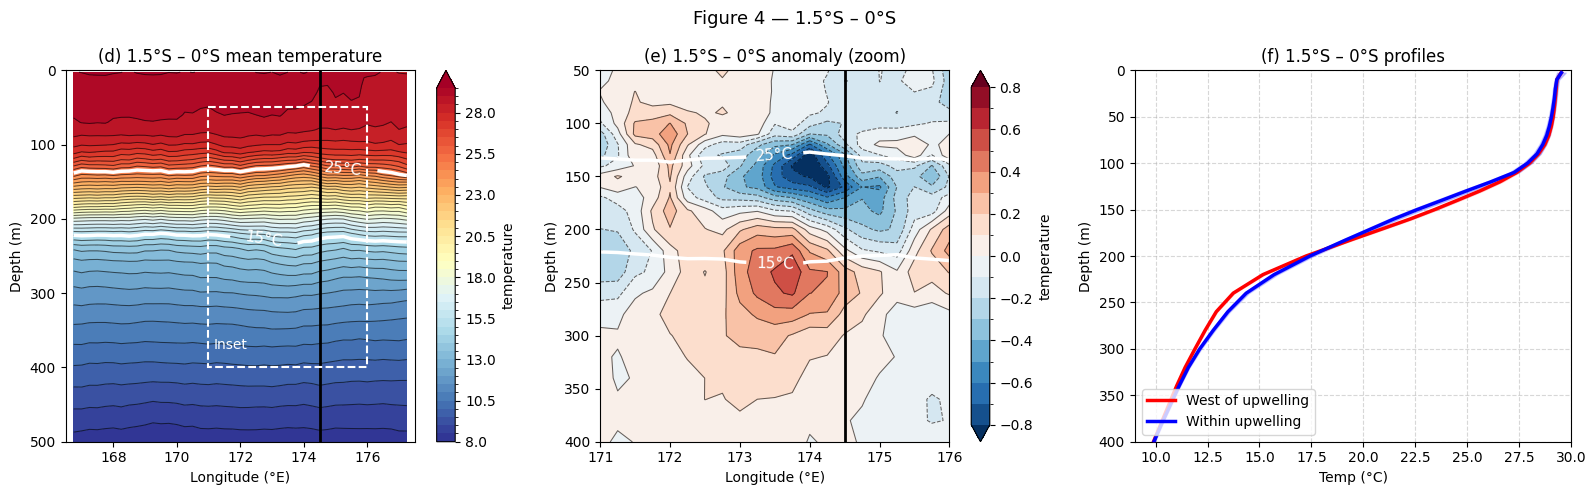

In [12]:
# ── Figure 4: Gilbert Islands — run, do not modify ─────────────────────────
depth_mask = slice(0, 34)
depth_plot = np.array(INTERPOLATION_LEVELS)[depth_mask]

for combined, grid, profiles, lat_label, upwelling_lon, west_of, row_label, island_lon, inset_lon_min, inset_lon_max in [
    (combined_north, grid_north, profiles_gil_north,
     '0°N – 2°N', (172.0, 173.5), 172.0, ['a','b','c'], 173.5, 169.5, 174.5),
    (combined_south, grid_south, profiles_gil_south,
     '1.5°S – 0°S', (172.5, 174.5), 172.5, ['d','e','f'], 174.5, 171.0, 176.0),
]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    plot_section(axes[0], combined, depth_mask, island_lon,
                 inset_lon_min, inset_lon_max, 50, 400,
                 label=f'({row_label[0]}) {lat_label}',
                 levels=np.arange(8, 30, 0.5),
                 xlim=(166.5, 177.5), ylim=(500, 0))

    plot_anomaly_zoom(axes[1], combined, depth_mask,
                      inset_lon_min, inset_lon_max, 50, 400,
                      island_lon=island_lon,
                      label=f'({row_label[1]}) {lat_label}')

    plot_profiles_comparison(axes[2], profiles, depth_mask, depth_plot,
                             upwelling_lon, west_of,
                             label=f'({row_label[2]}) {lat_label}')

    plt.suptitle(f'Figure 4 — {lat_label}', fontsize=13)
    plt.tight_layout()
    plt.show()
    

## ✏️ Student Work — Question 3: Comparing Vertical Temperature Profiles

Using the **middle and right panels** of Figures 3 and 4 (zonal anomaly and mean profiles):

1. For each region, compare the temperature profile **west of** the upwelling zone to the profile **within** the upwelling zone. At what depth is the difference largest? Does the thermocline appear shallower or deeper inside the upwelling zone?
2. Now compare the two island systems — Galápagos vs. Gilbert Islands (north and south). Are the upwelling signatures similar in depth, magnitude, and vertical extent?
3. What could explain any differences you observe between the two systems? Consider latitude, island geometry, the strength and direction of local winds, and the background equatorial ocean circulation.

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 4: Effect of Record Length

Now go back to the **Setup: configuration** cell and shorten the time period. Uncomment one of the alternative `time_periods` lines (start with the ~7-year window), then **re-run all cells from Step 1 onward**.

1. How do the SST maps and subsurface temperature sections change compared to the full 2000–2021 record? Are the upwelling cold anomalies more or less pronounced?
2. How does the number of Argo profiles change (Figure 2)? Does the spatial coverage remain similar, or are there any gaps?
3. What physical and statistical reasons could explain the differences you observe? Consider both the **ocean variability** (e.g., ENSO events, interannual SST anomalies) that may be over- or under-represented in a shorter window, and the **statistical uncertainty** associated with fewer profiles.
4. Try a second time window. Do the results get closer to the full-record result as you increase the time period? What does this suggest about the minimum record length needed to capture these upwelling systems reliably?


*Double-click to edit this cell and write your answers.*

### References

- **Karnauskas, K. B., and Giglio, D. (2022)** — Argo reveals the scales and provenance of equatorial island upwelling systems. *Geophysical Research Letters*, 49, e2022GL100071. https://doi.org/10.1029/2022GL100071